[*********************100%***********************]  4 of 4 completed
Inversión en AAPL: $249635.89, Número de acciones a comprar: 1926.91
Inversión en MSFT: $74184.07, Número de acciones a comprar: 883.14
Inversión en GOOGL: $296400.34, Número de acciones a comprar: 3359.41
Inversión en AMZN: $379779.70, Número de acciones a comprar: 1591.04

Valor total del portafolio: $1000000.00
Nuevos pesos del portfolio:
[0.24963589 0.07418407 0.29640034 0.3797797 ]


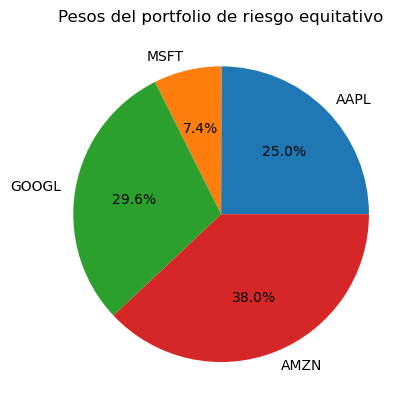

In [4]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Definir los símbolos de las acciones
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN']

# Obtener datos históricos de precios de cierre de las acciones
data = yf.download(tickers, start='2010-01-01', end='2022-12-31')['Adj Close']

# Calcular los retornos diarios de las acciones
returns = data.pct_change().dropna()

# Calcular la matriz de covarianza de los retornos
cov_matrix = returns.cov()

# Calcular los pesos de riesgo equitativo (risk parity weights)
inv_cov_matrix = np.linalg.inv(cov_matrix)
risk_parity_weights = inv_cov_matrix.sum(axis=1) / inv_cov_matrix.sum()

# Calcular los montos de inversión para cada acción
total_investment = 1000000  # Monto total de inversión
investment_amounts = total_investment * risk_parity_weights

# Calcular el número de acciones para comprar según los montos de inversión
current_prices = data.iloc[-1]  # Precios actuales de las acciones
num_shares = investment_amounts / current_prices

# Imprimir los montos de inversión y el número de acciones a comprar
for ticker, amount, shares in zip(tickers, investment_amounts, num_shares):
    print(f"Inversión en {ticker}: ${amount:.2f}, Número de acciones a comprar: {shares:.2f}")

# Calcular el valor total del portafolio
portfolio_value = sum(num_shares * current_prices)

print(f"\nValor total del portafolio: ${portfolio_value:.2f}")

# Imprimir los nuevos pesos
print("Nuevos pesos del portfolio:")
print(risk_parity_weights)

# Graficar un gráfico sectorial con el peso de cada acción
plt.pie(risk_parity_weights, labels=tickers, autopct='%1.1f%%')
plt.title('Pesos del portfolio de riesgo equitativo')
plt.show()